In [59]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from IPython.display import display, Markdown, Latex
import pandas as pd
from uncertainties import ufloat
from uncertainties import unumpy as unp
from scipy.optimize import curve_fit
from scipy import constants as const 
import math
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from lmfit import Model 

# PW 10 Thermodynamik
von Emilia Frei und Moritz Bacher

### 1. Erklärung der Grundlagen Experiment 1

In diesem Experiment ist die spezifische Wärmekapazität von Wasser zu bestimmen. Dafür bedient man sich folgender grundlegenden Formel:

$$
\Delta Q = C \cdot \Delta T
$$

wobei $\Delta Q$ die notwendige Wärmemenge beschreibt, $\Delta T$ den Temperaturanstieg und $Q$ die Wärmekapzität. 
<br>
<br>
Gemessen wird der Temperaturanstieg $\Delta T$. In diesem Aufbau wird ein Dewar mit 200g Wasser befüllt. Dieses wird durch eine Heizwendel, welches an einer Spannungsquelle von 6V angeschlossen ist, erwärmt. Durch Messungen von $U$ und $I$ kann die erbrachte Leistung des Heizwendels berechnet werden. So erhält man die Ausdrücke: 

$$
C_{ges} \cdot \Delta T = P_{el} \cdot \Delta t = U \cdot I \cdot \Delta t
$$
und 
$$
\Delta T = \frac{U \cdot I}{C_{ges}} \cdot \Delta t = \frac{U \cdot I}{C_k + C_W} \cdot \Delta t
$$

So lässt sich mithilfe eines linearen Fits der Funktion $\Delta T(\Delta t)$ die Steigung b berechnen, mit der man durch umformen schlussendlich die gesuchte spezifische Wärmekapazität $C_W$ berechnet werden: 
$$
C_W = \frac{U \cdot I}{b} - C_k
$$

wobei $C_k$ die Wärmekapazität des Kaloriemeters ist und gegeben ist durch $C_k = (135 ± 10)J \cdot K^{-1}$


### 2. Auswertung der Daten Experiment 1

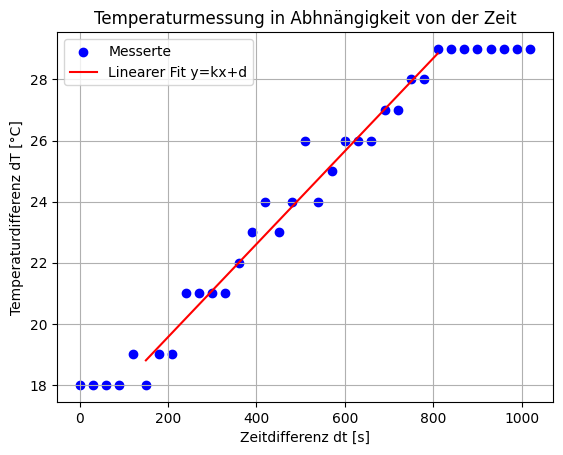

R^2 = 0.9617366791101464
Die Steigung beträgt 0.0152+/-0.0007 Grad/Sekunde.
Die Wärmekapazität des Wassers Cw beträgt (8.4+/-1.5)e+02 J/K, die spezifische Wärme des Wassers beträgt (4.1+/-0.8)e+03 J/K*kg.


In [60]:
#Code Auswertung Exp1

T0 = float(18) # ausgangstemperatur in grad c 

df = pd.read_csv("wärmekapazität.csv", sep=',', decimal='.', engine='python')
temperatur_gemessen = df.iloc[:, -2].to_numpy()
t = df["Time since start of measurement"].to_numpy() # gemessene Zeit

DT = temperatur_gemessen - T0 # delta temperatur, in K bzw C

md = ufloat(211.3, 0.05) # masse dewar in g
mwd = ufloat(416.2, 0.05) # masse wasser in dewar in g
mw_int = (mwd - md)*10**(-3) # masse wasser in g
u_mw = 0.05*10**(-3) # kg
#mw = ufloat(mw_int*10**{-3}, u_mw*10**{-3}) # in kg
mw = mw_int

Ck = ufloat(135, 10) # wärmekapazität des kalorimeters, J/K 

U1 = ufloat(5.98, 5.98*0.01+0.003) # bei anfangstemperatur, in V
I1 = ufloat(2.468, (2.468*0.012+0.5)) # bei anfangstemperatur, in A

U2 = ufloat(6.01, 6.01*0.01+0.003) # bei endtemperatur, in V
I2 = ufloat(2.468, 2.468*0.012+0.5) # bei endtemperatur, in A

P = ((U1+U2)/2)*((I1+I2)/2) # elektrische Leistung mit gemittelten Werten für U und I

x = t[5:-7] # zeit ohne werte bei denen noch nix passiert
y = temperatur_gemessen[5:-7] # temperatur ohne werte bei denen noch nix passiert

#def linear(b, x, d):
    #return b*x + d

model = Model(linear)

res = linregress(x, y)
#result = model.fit(y, x)
#result.fit_result()
#y_fit = result.best_fit


B = ufloat(res.slope, res.stderr)

y_fit = res.slope*x + res.intercept 

#ss_res = np.sum((y-y_fit)**2)
#ss_tot = np.sum((y-np.mean(y))**2)
#r2 = 1 - (ss_res/ss_tot)
r2=res.rvalue**2 

# der plot
plt.figure()
plt.scatter(t, temperatur_gemessen, marker="o", label="Messerte", color='blue')
plt.plot(x, y_fit, label="Linearer Fit y=kx+d", color='red')
plt.xlabel("Zeitdifferenz dt [s]")
plt.ylabel("Temperaturdifferenz dT [°C]")
plt.title("Temperaturmessung in Abhnängigkeit von der Zeit")
plt.legend()
plt.grid(True)
plt.show()

print(f"R^2 = {r2}")

Cw = (P/B)-Ck
cw = Cw/mw

print(f"Die Steigung beträgt {B} Grad/Sekunde.")
print(f"Die Wärmekapazität des Wassers Cw beträgt {Cw} J/K, die spezifische Wärme des Wassers beträgt {cw} J/K*kg.")






### 3. Erklärung der Grundlagen Experiment 2

In dem zweiten Experiment ist die Schmelzwärme S von Eis mithilfe der Mischungsmethode mit dem Kaloriemeter zu ermitteln. Man gibt auf etwa 0°C erwärmtes Eis in 70°C warmes Wasser und misst erneut die Änderung der Temperatur $\Delta T$ in Abhängigkeit von der Zeit $\Delta t$. Diese Werte werden erneut in einem Diagramm dargestellt und mithilfe von Extrapolation auf einen unendlich schnellen Temperaturausgleich wid die wahre Temperaturdifferenz zwischen Anfangstemperatur $T_1$ und Mischungstemperatur $T_m$ bestimmt.
<br>
<br>
Mithilfe von der Wärmekapazität des Kaloriemeters $C_k = (100 ± 10) J \cdot K^{-1}$ und der spezifischen Wärme des Wassers $c_W = 4.19 kJ \cdot kg^{-1} \cdot K^{-1}$ lässt sich die Schmelzwärme S ermitteln durch gleichsetzen von
$$
\Delta Q_1 = (C_k + m_W \cdot c_W) \cdot (T_1 - T_m)
$$
und 
$$
\Delta Q_2 = m_e \cdot S + m_e \cdot c_W \cdot (T_m - T_S)
$$

Es gilt also für S:
$$
S = \frac{(C_k + m_W \cdot c_W) \cdot (T_1 - T_m) - m_e \cdot c_W \cdot (T_m - T_S)}{m_e}
$$

### 4. Auswertung der Daten Experiment 2


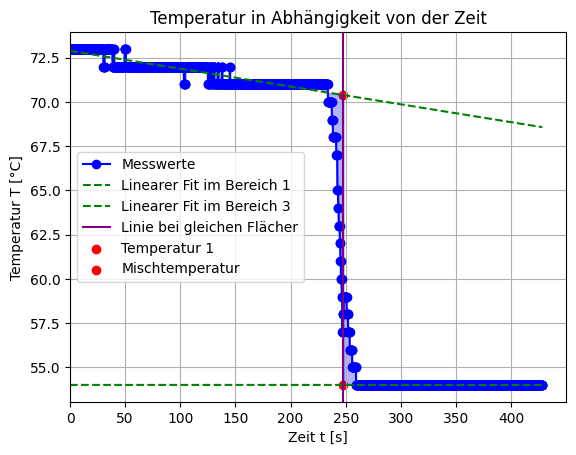

Die Schmelzwärme beträgt (2.71+/-0.21)e+05 J/kg


In [61]:
#Code Auswertung Exp2

me = ufloat(23.7,1) # masse eis
md = ufloat(211.3, 0.05) # masse dewar in g
mwd = ufloat(382.8, 0.05) # masse dewar mit wasser in g
mw = mwd-md # masse wasser
Ck = ufloat(100, 10) # wärmekapazität kalorimeter in J/K
cw = float(4.19*10**3) # spezifische Wärem Wasser, in J/kg*K


df = pd.read_csv("schmelzwärme.csv", sep=',', decimal='.', engine='python')
T = df.iloc[:, -2].to_numpy()
t = df["Time since start of measurement"].to_numpy()

# fits 
#I = np.where(t <= 914)[0] # hier die uhrzeit, zu der wir das eis hineingegeben haben, eintragen
#II = np.where(t >= 1060)[0] # zeitpunkt, zu dem das eis weg ist??
I = 914
II = 1060

t0 = 248 # beispielwert zum ausprobieren 

# abschnitt 1
x1 = t[0:I]
y1 = T[0:I]

res1 = linregress(x1, y1)


def linfit1(k, x1, d):
    return k*x1 + d

#fit1 = Model(linfit1)
#result = fit1.fit(y1, x1, k=1, d=0)
#result.fit_result()
#y1_fit = result.best_fit

y1_fit = res1.slope*t + res1.intercept

x1_plot = t 
y1_plot = y1_fit 
T_1 = res1.slope*t0 + res1.intercept 
#x1_plot = np.linspace(t.min(), t.max(), 100)
#y1_plot = result.params['k'].value * x1_plot + result.params['d'].value
#T_1 = result.params['k'].value * t0 + result.params['d'].value
#T_1_ = ufloat(T_1.nominal_value, ) # T_1 mit eigener Unsicherheit, könnten wir aus dem fit nehmen??

# abschnitt 3
x3 = t[II:]
y3 = T[II:]

#def linfit3(a, x3, b):
    #return a*x3 + b 

#fit3 = Model(linfit3) 
#result = fit3.fit(y3, x3, a=1, b=0)
#result.fit_result()
#y3_fit = result.best_fit

#x3_plot = np.linspace(t.min(), t.max(), 100)
#y3_plot = result.params['a'].value * x3_plot + result.params['b'].value
#T_m = result.params['a'] * t0 + result.params['b'].value
#T_m_ = ufloat(T_m.nominal_value, ) # T_m mit eigener Unsicherheit

res3 = linregress(x3, y3)
y3_fit = res3.slope*t + res3.intercept
x3_plot = t 
y3_plot = y3_fit
T_m = res3.slope*t0 + res3.intercept

T_S = 0

#Ich nenne hier die Anfangstemperatur T_1 (Fit von I ausgewertet bei t0) und die Mischtemperatur T_m (Fit von III ausgewertet bei t0), die Schmelztemperatur T_S ist 0 (nicht sicher, deswegen lasse ich es mal)

S = ((Ck + mw * cw) * (T_1 - T_m) - me * cw * (T_m - T_S))/me # hier ev T_1 und T_m ändern mit _ danach für eigene Unsicherheiten
S_nom = S.nominal_value

# plot
plt.figure()
plt.plot(t, T, marker='o', label="Messwerte", color='blue')
plt.plot(x1_plot, y1_plot, "--", label="Linearer Fit im Bereich 1", color='green')
plt.plot(x3_plot, y3_plot, "--", label="Linearer Fit im Bereich 3", color='green')
plt.axvline(t0, linestyle="-", label="Linie bei gleichen Flächer", color='purple') # einsetzen!!
plt.xlabel("Zeit t [s]")
plt.scatter(t0, T_1, marker="o", color='red', label="Temperatur 1")
plt.scatter(t0, T_m, marker="o", color='red', label="Mischtemperatur")
#plt.scatter(t0, S_nom, marker="o", color='red', label="Spezifische Schmelzwärme")
plt.fill_between(t[I:II], T[I:II], y1_plot[I:II], where=(t[I:II] <= t0), alpha=0.3, color='blue')
plt.fill_between(t[I:II], T[I:II], y3_plot[I:II], where=(t[I:II] >= t0), alpha=0.3, color='blue')
plt.ylabel("Temperatur T [°C]")
plt.title("Temperatur in Abhängigkeit von der Zeit")
plt.xlim(left=0)
plt.legend()
plt.grid(True)
plt.show()

r2o = res1.rvalue**2
r2u = res3.rvalue**2

print(f"Die Schmelzwärme beträgt {S} J/kg")


### 5. Diskussion

Die spezifische Wärmekapazität beträgt laut Literaturwerten 4,1 kJ/K*kg [https://www.leifiphysik.de/waermelehre/innere-energie-waermekapazitaet/grundwissen/spezifische-waermekapazitaet].
Literaturwerten zufolge ist Schmelzwärme von Eis in etwa 335 kJ/kg [https://www.leifiphysik.de/waermelehre/innere-energie-waermekapazitaet/versuche/schmelzwaerme-von-eis]. 
